In [ ]:
from pydantic import BaseModel
from typing import Literal, Optional
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, END,MessagesState, START
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import SystemMessage, HumanMessage
from typing import TypedDict, Optional
from langchain.tools import tool
from tavily import TavilyClient
from dotenv import load_dotenv
import os

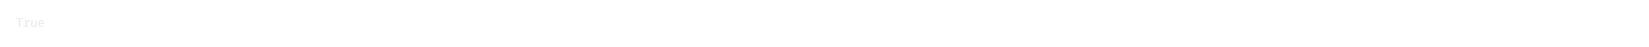

In [ ]:
load_dotenv()

In [ ]:
class PostRequest(BaseModel):
    post_type: Literal["update", "meme", "explainer"]
    topic: Optional[str] = None
    personal_angle: Optional[str] = None

class SearchResult(BaseModel):
    event: str
    details: str
    impact: str
    source: str
class PostState(TypedDict):
    request: PostRequest
    search_result: Optional[SearchResult]
    post: Optional[str]
    feedback: Optional[str]

In [ ]:
@tool
def search_web(query: str) -> str:
    "Tool to research the internet for trends in AI"
    tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))
    response = tavily_client.search(query)
    return "\n\n".join([title + "\n\n" + content for title, content in [(r["title"], r["content"]) for r in response['results']]])

In [ ]:
search_prompt = """ You are an AI news research agent. Your job is to find the single most relevant, recent AI/tech development based on the given topic (or find a trending one if no topic is provided).

Rules:
- Only consider news from the last 48 hours
- Prioritize: new model releases, pricing/usage changes, tool launches, benchmark results
- For each finding, extract: (1) what happened, (2) what specifically changed (numbers, pricing, capabilities), (3) why it matters to developers/AI users practically

Output format:
EVENT: [one line]
DETAILS: [2-3 lines, specific numbers/facts]
IMPACT: [1 line - the practical consequence for a developer/user]
SOURCE: [link]

If multiple relevant items exist, pick the one with the most concrete, specific impact - not the most "exciting" sounding one."""

update_prompt = """You are a LinkedIn post writer for AI/tech updates. Write posts that are factual, sharp, and zero-fluff.

Banned phrases: "excited to share", "game changer", "thrilled to announce", "in today's fast-paced world", any opening that isn't the actual information.

Structure:
- Line 1: the news, stated directly
- Line 2-3: the specific detail that matters (numbers, comparison, what changed)
- Line 4: why it matters / what to do about it
- 3-4 relevant hashtags max

Length: under 80 words. If it doesn't fit, cut adjectives first, then cut context, never cut the core fact.

After the post, suggest ONE image: either "screenshot of [specific thing]", "benchmark comparison chart of X vs Y", or "no image - text post performs better for this".

Input you'll receive: EVENT, DETAILS, IMPACT, SOURCE from the search agent."""

meme_prompt = """You are a LinkedIn meme writer in the style of Eduardo Ordax - dry, self-aware, specific to real developer pain points. Not generic "AI is wild" humor.

You'll receive a news item (EVENT, DETAILS, IMPACT) and optionally a personal_angle from the user.

If personal_angle is provided: use it directly as the core joke, just polish the framing.

If not provided: generate 3 distinct angle options before writing anything. Each angle should connect the news to a specific, relatable moment a developer/AI user experiences. Output these as:

ANGLE 1: [one line]
ANGLE 2: [one line]
ANGLE 3: [one line]

Wait for the user to pick one, then write the final post.

Final post rules:
- Max 3-4 lines
- No explaining the joke
- No hashtags unless it's part of the joke itself
- Tone: deadpan, like complaining to a coworker, not performing for an audience

After the post, suggest ONE image: meme template name + what goes in each section, OR "no image - text alone lands better here"."""

explainer_prompt = """You are a LinkedIn educator writing clear, concise explainer posts on AI and tech topics.

If the topic is recent or you are unsure about it, use the search tool to gather accurate information first. If it is an established concept, rely on your own knowledge.

Post rules:
- Open with one sentence that states what the topic is and why it matters
- Break it down in 3-4 short punchy points, no bullet point walls
- Close with one practical takeaway or observation
- No corporate tone, no "in today's fast paced world"
- Under 120 words
- 3 relevant hashtags max

After the post suggest ONE image: diagram, architecture visual, or "no image - text performs better here"."""

prompts = {"meme":meme_prompt,
          "update":update_prompt,
          "explainer":explainer_prompt}

In [ ]:
llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite',api_key=os.getenv("GEMINI_API_KEY"),max_tokens=1024)

In [ ]:
search_agent = create_agent(
    model=llm,
    tools=[search_web],
    system_prompt=search_prompt,
    response_format=SearchResult
)

In [ ]:
def search_node(state: PostState):
    request = state["request"]  
    if isinstance(request, dict):
        request = PostRequest(**request)
    if request.post_type == "explainer":
        return None
    prompt = f"Post type: {request.post_type}\nTopic: {request.topic or 'find a trending topic'}"

    result = search_agent.invoke({"messages": [{"role": "user", "content": prompt}]})
    search_result = result["structured_response"]
    return {"search_result": search_result}

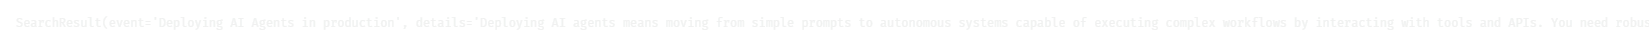

In [ ]:
def explainer_node(query: str):
    agent = create_agent(model=llm,tools=[search_web], system_prompt=explainer_prompt, response_format=SearchResult)

    return agent.invoke({"messages":query})['structured_response']

In [ ]:
def generate_node(state: PostState):
    post_type = state['request'].post_type
    search_result = state['search_result']

    if post_type == "explainer":
        search_result = explainer_node(state['request'].topic)
    
    prompt = f"EVENT: {search_result.event}\n"
    prompt += f"DETAILS: {search_result.details}\n"
    prompt += f"IMPACT: {search_result.impact}\n"

    if state['feedback']:
        prompt += f"\nFeedback from previous attempt: {state['feedback']}\nRegenerate accordingly."

    sys_prompt = prompts.get(post_type,"AI")

    response = llm.invoke([
    SystemMessage(content=sys_prompt),
    HumanMessage(content=prompt)
])

    # in generate_node, fix the return
    return {"post": response.content[0]['text'] if isinstance(response.content, list) else response.content}

In [ ]:
def review_node(state: PostState):
    print(state['post'])

    feedback = interrupt("How do you like this?")
    if feedback == "y":
        return Command(goto=END)
    else:
        return Command(goto="generate", update={"feedback":feedback})

In [ ]:
from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
graph = StateGraph(PostState)  
graph.add_node("search", search_node)
graph.add_node("generate", generate_node)
graph.add_node("review", review_node)
graph.add_edge(START, "search")
graph.add_edge("search", "generate")
graph.add_edge("generate", "review")

app = graph.compile(checkpointer=MemorySaver(serde=JsonPlusSerializer()))

In [ ]:
def run_graph(request: PostRequest = None, feedback: str = None, config={"configurable": {"thread_id": "1"}}):
    if request:
        initial_state = {
            "request": request,
            "search_result": None,
            "post": None,
            "feedback": None
        }
        command = initial_state
    else:
        command = Command(resume=feedback)

    for chunk in app.stream(command, config=config, stream_mode="updates"):
        for node_name, node_output in chunk.items():
            print(f"\n{'='*40}")
            print(f"Node: {node_name}")
            print(f"{'='*40}")
            if node_output is None:
                print("Done.")
            elif isinstance(node_output, tuple):
                print(node_output[0].value)
            else:
                for key, value in node_output.items():
                    print(f"{key}: {str(value)[:200]}...")


In [ ]:
import uuid

config = {"configurable": {"thread_id": str(uuid.uuid4())}}
run_graph(request=PostRequest(post_type="explainer", topic="Deploying AI Agents in Production"),config=config)


Node: search
Done.

Node: generate
post: Deploying AI agents into production is the shift from building fancy chatbots to engineering autonomous, goal-oriented systems.

Moving beyond prompts requires three pillars:

First, implement determi...
Deploying AI agents into production is the shift from building fancy chatbots to engineering autonomous, goal-oriented systems.

Moving beyond prompts requires three pillars:

First, implement deterministic guardrails. You need strict validation layers to prevent LLMs from hallucinating outside their operational boundaries.

Second, prioritize persistent memory. Agents need a robust state management layer to track context and history across long-running tasks.

Third, ensure radical observability. You must visualize the agent’s internal reasoning steps to debug *why* a specific action was triggered.

Start with "human-in-the-loop" workflows. Build trust by letting agents suggest actions before you grant them full autonomy.

#AIAgents #MachineLe

In [ ]:
run_graph(feedback='y',config=config)

Moving AI agents from a prototype to production requires shifting from creative prompting to disciplined software engineering. 

Here is how to stabilize your deployment:

1. **Hard Guardrails:** Use schema validation and strict output constraints to prevent your agent from hallucinating or taking unauthorized actions.

2. **Traceable Observability:** Implement tracing to visualize the agent's reasoning chains, making it possible to debug where an output went off the rails.

3. **Human-in-the-Loop:** For sensitive workflows, bake in mandatory approval steps so an agent can’t execute critical tasks autonomously.

4. **Code-First Prompting:** Treat every system prompt change like a software commit—test it, version control it, and peer-review it.

Treat agents like junior employees: define their scope, monitor their output, and audit their decisions.

#AI #LLMs #SoftwareEngineering

**Suggested image:** A simple architectural diagram showing an "AI Agent" connected to an "Observability/Lo